In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import fsrs_optimizer
import numpy as np

tqdm.pandas()

/home/luc/Programming/forks/fatigue-graph/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 321
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

265645

In [5]:
df.describe()

,card_id,day_offset,rating,elapsed_days,duration
count,53129.000000,53129.000000,53129.000000,53129.000000,53129.000000
mean,978.700183,840.663065,2.450526,81.783583,7839.792806
std,536.471282,788.058298,0.728817,153.835329,5857.430518
min,0.000000,0.000000,1.000000,-1.000000,1212.000000
25%,509.000000,230.000000,2.000000,3.000000,4330.000000
50%,1008.000000,490.000000,2.000000,14.000000,6263.000000
75%,1468.000000,1365.000000,3.000000,84.000000,9279.000000
max,1852.000000,2837.000000,4.000000,1871.000000,60000.000000


In [6]:
df[df["card_id"] == 230]

,card_id,day_offset,rating,elapsed_days,duration
5694,230,198,1,-1,8799
5695,230,198,3,0,4163
5696,230,198,3,0,6927
5697,230,200,2,2,8173
5698,230,204,3,4,8734
5699,230,214,3,10,9996
5700,230,237,2,23,8995
5701,230,263,3,26,6404
5702,230,323,2,60,18085
5703,230,391,3,68,5151


In [7]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()

In [8]:
print("creating time series")
df["delta_t"] = df["elapsed_days"]
df: pd.DataFrame = create_time_series(df)
print("training")
trainer = fsrs_optimizer.Trainer(df, df, fsrs_optimizer.DEFAULT_PARAMETER)
w = trainer.train()

creating time series
training


KeyboardInterrupt: 

In [ ]:
import math

DECAY = -0.5
FACTOR = 0.9 ** (1 / DECAY) - 1

def power_forgetting_curve(t, s):
    return (1 + FACTOR * t / s) ** DECAY

def stability_after_success(s, r, d, rating):
    hard_penalty = w[15] if rating == 2 else 1
    easy_bonus = w[16] if rating == 4 else 1
    return max(
        0.01,
        s * (
            1
            + math.exp(w[8])
            * (11 - d)
            * (s ** -w[9])
            * (math.exp((1 - r) * w[10]) - 1)
            * hard_penalty
            * easy_bonus
        )
    )

def stability_after_failure(s, r, d):
    return max(
        0.01,
        min(
            w[11]
            * (d ** -w[12])
            * ((s + 1) ** w[13] - 1)
            * math.exp((1 - r) * w[14]),
            s / math.exp(w[17] * w[18])
        )
    )

def stability_short_term(s, init_rating=None):
    if init_rating is not None:
        rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[init_rating - 1]
        session_len = fsrs_optimizer.DEFAULT_FIRST_SESSION_LENS[init_rating - 1]
    else:
        rating_offset = fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET
        session_len = fsrs_optimizer.DEFAULT_FORGET_SESSION_LEN
    
    new_s = s * math.exp(
        w[17] * (rating_offset + session_len * w[18])
    )
    return new_s

def init_d(rating):
    return w[4] - math.exp(w[5] * (rating - 1)) + 1

def init_d_with_short_term(rating):
    rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[rating - 1]
    new_d = init_d(rating) - w[6] * rating_offset
    return max(1, min(new_d, 10))

def linear_damping(delta_d, old_d):
    return delta_d * (10 - old_d) / 9

def mean_reversion(init, current):
    return w[7] * init + (1 - w[7]) * current

def next_d(d, rating):
    delta_d = -w[6] * (rating - 3)
    new_d = d + linear_damping(delta_d, d)
    new_d = mean_reversion(init_d(4), new_d)
    return max(1, min(new_d, 10))


In [ ]:
def memory_state(df):
    t_history = [int(t) for t in df["t_history"].split(",")]
    r_history = [int(r) for r in df["r_history"].split(",")]
    difficulty = None
    stability = None
    retrievability = 1e-10
    for delta_t, rating in zip(t_history, r_history):
        if stability is None:  # New card
            difficulty = init_d_with_short_term(rating)
            stability = stability_short_term(w[rating - 1], init_rating=rating)
        else:
            retrievability = power_forgetting_curve(delta_t, stability)
            if rating > 1:
                stability = stability_after_success(
                    stability, retrievability, difficulty, rating
                )
            else:
                stability = stability_after_failure(stability, retrievability, difficulty)
                stability = stability_short_term(stability)
            difficulty = next_d(difficulty, rating)
            if rating == 1:
                difficulty -= (w[6] * fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET)
                difficulty = min(max(difficulty, 1), 10)

    return stability, difficulty, retrievability


df["s"], df["d"], df["r"] = zip(*df.progress_apply(memory_state, axis=1))

100%|██████████| 44434/44434 [00:02<00:00, 21557.43it/s]


In [ ]:
df["loss"] = df.apply(lambda df: (df["y"] - df["r"]) ** 2, axis=1)
df["duration"] = (df["duration"] / 1000).round(0)

Average Very Young cards per day 163.21428571428572


<Figure size 640x480 with 0 Axes>

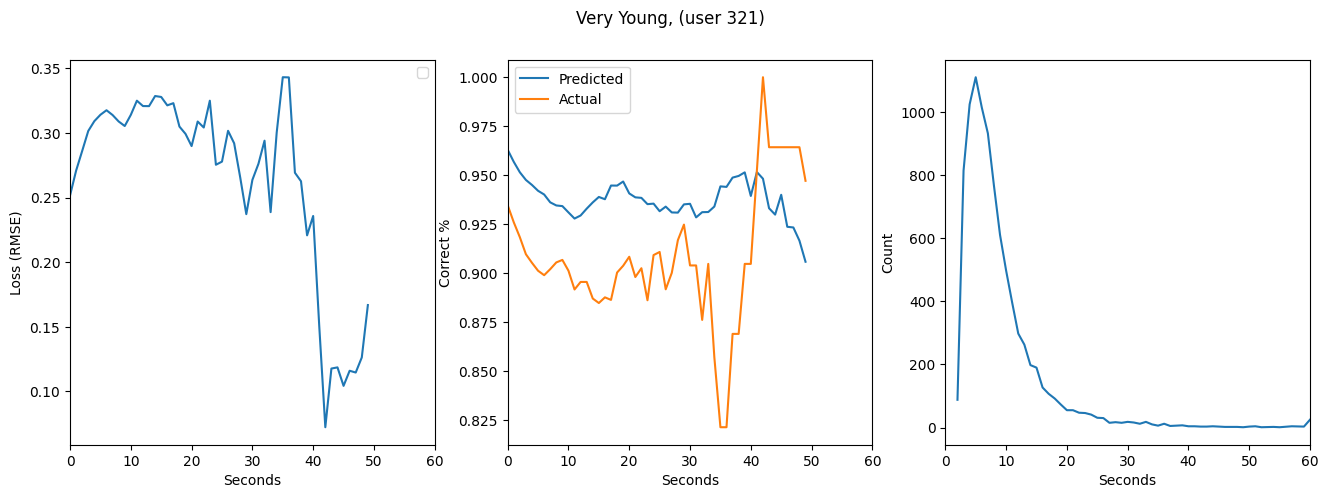

Average Young cards per day 357.6333333333333


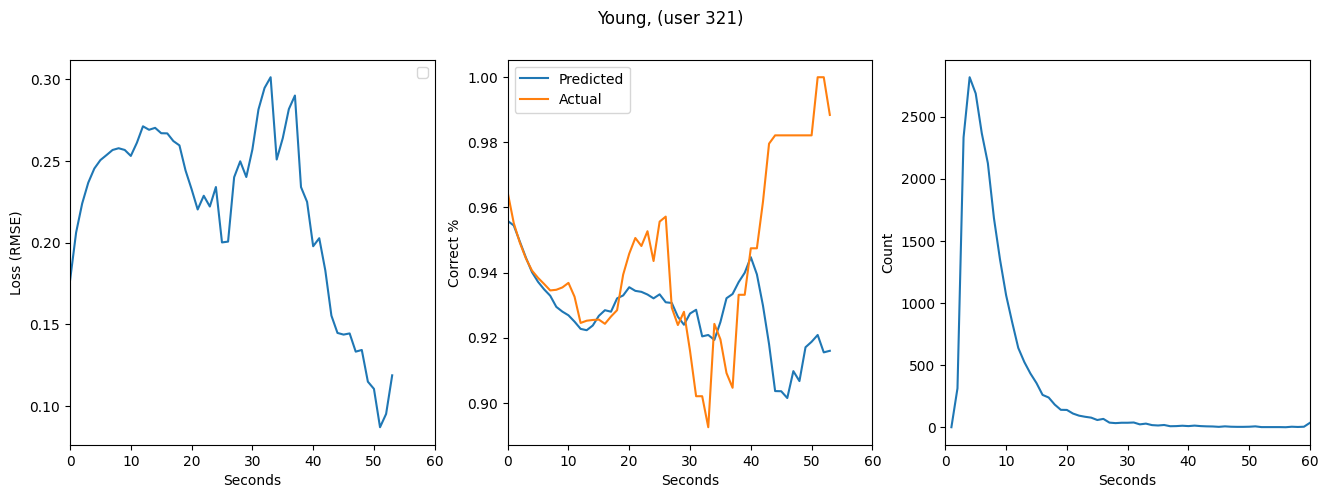

Average Mature cards per day 410.23214285714283


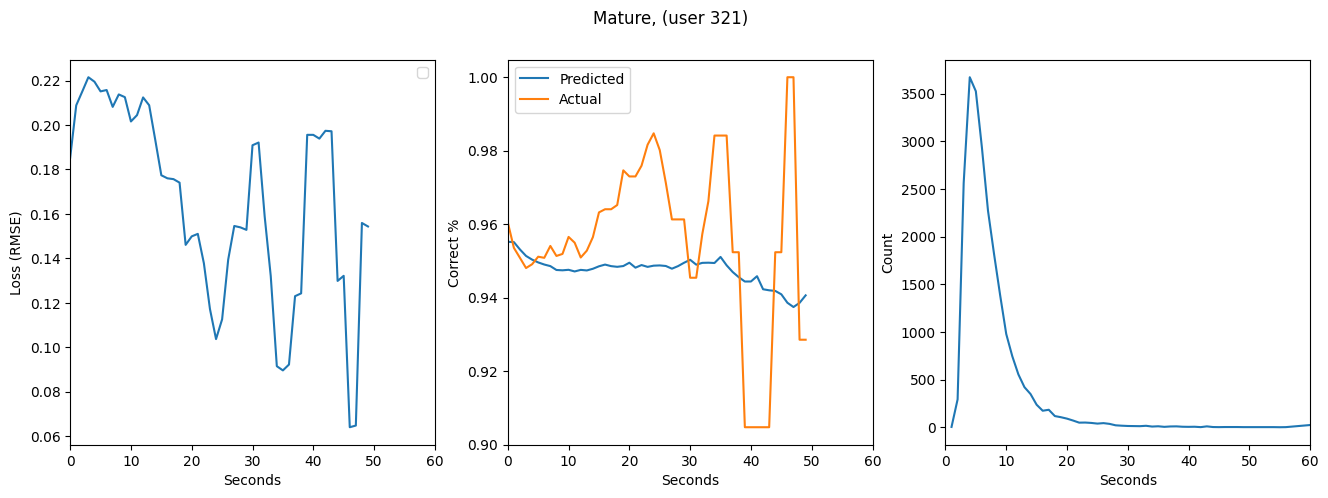

Average All cards per day 740.5166666666667


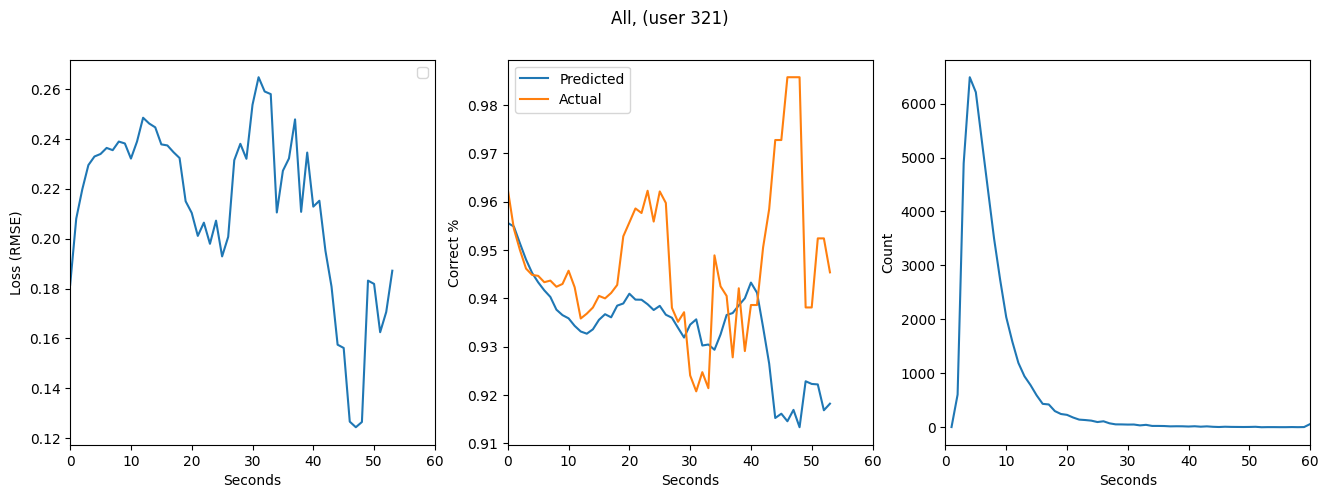

In [ ]:
plt.clf()
categories = [
    #("Learn", -1, 1), 
    ("Very Young", 0, 4), 
    ("Young", 0, 21), 
    ("Mature", 21, 1e20),
    ("All", -1, 1e20)
]

# https://stackoverflow.com/a/54628145/24162642
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

for name, lower, upper in categories:
    df_filtered = df[(df["elapsed_days"] > lower) & (df["elapsed_days"] <= upper) & (df["r"] > 1e-9)].groupby("duration")

    print(f"Average {name} cards per day {df_filtered['card_id'].count().mean()}")
    loss = df_filtered["loss"].mean() ** 0.5
    loss = moving_average(loss, 7)

    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{name}, (user {USER_ID})")
    ax1 = fig.add_subplot(131)
    xlim = 60

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Loss (RMSE)')
    ax1.plot(loss)
    ax1.legend()
    ax1.set_xlim(0, xlim)


    ax2 = fig.add_subplot(132)

    ax2.plot(moving_average(df_filtered["r"].mean(), 7), label="Predicted")
    ax2.plot(moving_average(df_filtered["y"].mean(), 7), label="Actual")
    ax2.set_xlabel('Seconds')
    ax2.set_ylabel('Correct %')
    ax2.set_xlim(0, xlim)
    ax2.legend()

    ax3 = fig.add_subplot(133)

    ax3.plot(df_filtered["r"].count())
    ax3.set_xlabel('Seconds')
    ax3.set_ylabel('Count') # Number of days that the user had that many reviews or more
    ax3.set_xlim(0, xlim)

    plt.show()


In [12]:
df_filtered = df #[df["elapsed_days"] > 0]
df_filtered.sort_values("elapsed_days", inplace=True)

rating
1.0    8182.719947
2.0    7957.833625
3.0    7803.841772
4.0    6304.637987
Name: duration, dtype: float64

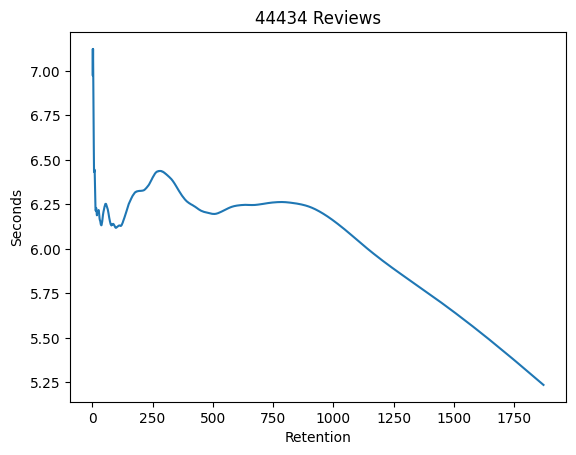

In [ ]:
from utils import moving_average

x = df_filtered["elapsed_days"]
y = df_filtered["duration"] / 1000

plt.plot(*moving_average(x, y))
plt.xlabel("Elapsed_days")
plt.ylabel("Seconds")
plt.title(f"{len(df_filtered)} Reviews")

#plt.xlim((0.7, 0.99))

df_filtered.groupby("rating")["duration"].mean()

rating
1.0    7.856859
2.0    7.898075
3.0    7.777396
4.0    6.268466
Name: duration, dtype: float64

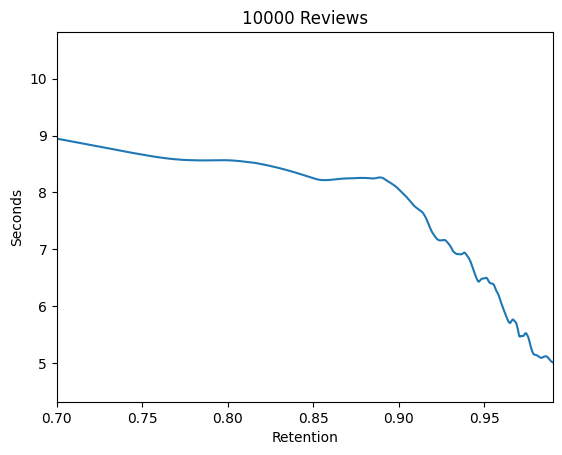

In [ ]:
N = 10_000
df_sampled = df_filtered.sample(N)

x = df_sampled["r"]
y = df_sampled["duration"]

plt.plot(*moving_average(x, y))
plt.xlabel("Retention")
plt.ylabel("Seconds")
plt.title(f"{len(df_sampled)} Reviews")

plt.xlim((0.7, 0.99))

df_sampled.groupby("rating")["duration"].mean()